# Pipeline 3 - Donor Churn Risk System

## 1) Problem Framing

**Business question:** Which monetary donors are at risk of becoming inactive (churning), and what factors explain that risk?

**Who cares and why:** The fundraising team and organizational leadership depend on donor retention for financial sustainability. With only ~57 monetary donors, losing even 2-3 donors per year has significant financial impact. Early identification of at-risk donors allows proactive outreach before they lapse.

### Approach

This pipeline uses a **hybrid decisioning strategy:**
- **Deterministic rule tiers** drive immediate intervention (`Critical/High/Medium/Low`) based on recency and gap trends.
- **ML probability score** provides an additional risk signal and improves with more historical outcomes.
- **Explanatory companion model** (logistic regression with coefficient analysis) identifies which donor behaviors most strongly explain churn risk.

### Prediction vs. Explanation

The primary model is **predictive** â€” we optimize for ROC-AUC to rank donors by churn risk. We complement it with an **explanatory** logistic regression model to understand *why* donors churn (coefficient interpretation, odds ratios).

### Error Cost Discussion

- **False positive** (flag non-churning donor as at-risk): Staff reach out unnecessarily â€” wasted effort but low harm. Could even strengthen the relationship.
- **False negative** (miss a churning donor): Revenue loss â€” more costly. A lapsed donor is much harder to reactivate than to retain.
- **Implication:** We should tune toward **recall** (catch at-risk donors, accept more false alarms). Threshold selection below will explore this trade-off.

### Primary Metrics
- ROC-AUC (discrimination ability)
- Recall at the selected threshold (sensitivity to churners)
- F1 (balance metric)

### Dataset Limitation
- Only 57 monetary donors with ~25% churn rate (14 churned). This is very small; results should be treated as directional, not definitive.

> **Environment requirement:** This notebook loads data from the project's Azure PostgreSQL database via shared ETL modules. To run top-to-bottom, you need:
> 1. A `.env` file in the repo root with valid database credentials (see `.env.example`)
> 2. Python packages from `ml/requirements.txt` installed (`pip install -r ml/requirements.txt`)
> 3. Network access to `intex-db.postgres.database.azure.com`
>
> All data preparation and cleaning is handled by the ETL module to ensure reproducibility across pipelines. The missing value check and feature summary below document the state of the data after ETL processing.

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import sys, os, json as _json
from pathlib import Path
from datetime import date, datetime, timezone
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    RandomForestClassifier, StackingClassifier,
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, f1_score, roc_auc_score,
    precision_recall_curve, precision_score, recall_score, confusion_matrix,
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score, learning_curve,
    train_test_split, validation_curve,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# ── Database connection (inlined from ml/config.py + ml/utils_db.py) ─────
from dotenv import load_dotenv
from sqlalchemy import create_engine

env_candidates = [Path.cwd(), Path.cwd().parent]
for p in env_candidates:
    for name in [".env", "ml/.env"]:
        env_path = p / name
        if env_path.exists():
            load_dotenv(env_path)

DATABASE_URL = os.environ["DATABASE_URL"]
engine = create_engine(DATABASE_URL, pool_pre_ping=True)

def fetch_table(table_name):
    df = pd.read_sql_table(table_name, engine)
    df.columns = pd.Index([str(c) for c in df.columns])
    return df

# ── Feature helpers (inlined from ml/donor_churn/features.py) ────────────

def _to_naive_timestamp(value: pd.Timestamp) -> pd.Timestamp:
    """Return timezone-naive timestamp for safe arithmetic."""
    if value.tzinfo is not None:
        return value.tz_localize(None)
    return value

def _normalize_date(value):
    if value is None:
        return _to_naive_timestamp(pd.Timestamp.utcnow()).normalize()
    parsed = pd.to_datetime(value, errors="coerce")
    if pd.isna(parsed):
        return _to_naive_timestamp(pd.Timestamp.utcnow()).normalize()
    return _to_naive_timestamp(pd.Timestamp(parsed)).normalize()

def _safe_mean(values):
    seq = list(values)
    if not seq:
        return 0.0
    return float(pd.Series(seq, dtype="float64").mean())

def _trend_delta(values, window=3):
    if not values:
        return 0.0
    if len(values) == 1:
        return 0.0
    first = values[:window]
    last = values[-window:]
    return _safe_mean(last) - _safe_mean(first)

def compute_rule_tier(recency_days, gap_trend):
    """Deterministic donor-risk tier from operational thresholds."""
    if recency_days > 180:
        return "Critical"
    if recency_days > 90:
        return "High"
    if recency_days > 30 or gap_trend > 30:
        return "Medium"
    return "Low"

def compute_top_risk_factors(recency_days, gap_trend):
    """Return triggered rule conditions for metadata transparency."""
    factors = []
    if recency_days > 180:
        factors.append("recency_days > 180")
    elif recency_days > 90:
        factors.append("recency_days > 90")
    elif recency_days > 30:
        factors.append("recency_days > 30")
    if gap_trend > 30:
        factors.append("gap_trend > 30")
    return factors

def build_donor_feature_frame(supporters, donations, social_posts=None, as_of_date=None):
    """Build one row per monetary donor with model-ready features."""
    as_of = _normalize_date(as_of_date)
    df_d = donations.copy()
    df_d["donation_type"] = df_d.get("donation_type", "").astype(str)
    df_d = df_d[df_d["donation_type"].str.lower().eq("monetary")].copy()
    if df_d.empty:
        return pd.DataFrame(columns=["supporter_id"])

    df_d["supporter_id"] = pd.to_numeric(df_d["supporter_id"], errors="coerce")
    df_d = df_d[df_d["supporter_id"].notna()].copy()
    df_d["supporter_id"] = df_d["supporter_id"].astype(int)
    df_d["donation_date"] = pd.to_datetime(df_d.get("donation_date"), errors="coerce").dt.tz_localize(None)
    df_d["amount"] = pd.to_numeric(df_d.get("amount"), errors="coerce").fillna(0.0)
    df_d["is_recurring"] = df_d.get("is_recurring", False).fillna(False).astype(bool)
    df_d["campaign_name"] = df_d.get("campaign_name", "").fillna("").astype(str).str.strip()
    df_d = df_d[df_d["donation_date"].notna()].copy()
    df_d = df_d.sort_values(["supporter_id", "donation_date"]).reset_index(drop=True)

    s = supporters.copy()
    s["supporter_id"] = pd.to_numeric(s["supporter_id"], errors="coerce")
    s = s[s["supporter_id"].notna()].copy()
    s["supporter_id"] = s["supporter_id"].astype(int)
    s = s.drop_duplicates("supporter_id")

    donor_ids = sorted(df_d["supporter_id"].unique().tolist())
    s = s[s["supporter_id"].isin(donor_ids)].copy()

    records = []
    for supporter_id, grp in df_d.groupby("supporter_id", sort=False):
        grp = grp.sort_values("donation_date")
        donation_dates = grp["donation_date"].tolist()
        amounts = grp["amount"].astype(float).tolist()

        first_date = donation_dates[0]
        last_date = donation_dates[-1]
        recency_days = float(max((as_of - last_date.normalize()).days, 0))
        frequency = int(len(grp))
        monetary_total = float(sum(amounts))
        monetary_avg = float(monetary_total / frequency) if frequency else 0.0
        monetary_last = float(amounts[-1]) if amounts else 0.0
        tenure_days = float(max((last_date.normalize() - first_date.normalize()).days, 0))
        is_recurring = int(bool(grp["is_recurring"].any()))

        gaps = grp["donation_date"].diff().dt.days.dropna().astype(float).tolist()
        avg_gap_days = _safe_mean(gaps)
        gap_trend = _trend_delta(gaps)
        amount_trend = _trend_delta(amounts)

        campaign_response_rate = 0.0
        missed_campaigns = 0.0
        if social_posts is not None and not social_posts.empty:
            campaigns = social_posts.copy()
            campaigns["campaign_name"] = campaigns.get("campaign_name", "").fillna("").astype(str).str.strip()
            campaigns["created_at"] = pd.to_datetime(campaigns.get("created_at"), errors="coerce").dt.tz_localize(None)
            campaigns = campaigns[(campaigns["campaign_name"] != "") & (campaigns["created_at"].notna())].copy()
            if not campaigns.empty:
                first_campaign_dates = (
                    campaigns.sort_values("created_at")
                    .drop_duplicates("campaign_name", keep="first")[["campaign_name", "created_at"]]
                )
                exposure = first_campaign_dates[
                    (first_campaign_dates["created_at"] >= first_date.normalize())
                    & (first_campaign_dates["created_at"] <= as_of)
                ]["campaign_name"]
                exposed = set(exposure.tolist())
                responded = set(grp.loc[grp["campaign_name"] != "", "campaign_name"].tolist()) & exposed
                if exposed:
                    campaign_response_rate = float(len(responded) / len(exposed))
                    missed_campaigns = float(len(exposed) - len(responded))

        records.append({
            "supporter_id": int(supporter_id),
            "recency_days": recency_days,
            "frequency": float(frequency),
            "monetary_total": monetary_total,
            "monetary_avg": monetary_avg,
            "monetary_last": monetary_last,
            "avg_gap_days": avg_gap_days,
            "gap_trend": gap_trend,
            "amount_trend": amount_trend,
            "tenure_days": tenure_days,
            "is_recurring": float(is_recurring),
            "campaign_response_rate": campaign_response_rate,
            "missed_campaigns": missed_campaigns,
        })

    features = pd.DataFrame(records)
    merged = features.merge(
        s[["supporter_id", "acquisition_channel", "relationship_type"]],
        on="supporter_id",
        how="left",
    )
    merged["acquisition_channel"] = merged["acquisition_channel"].fillna("Unknown").astype(str)
    merged["relationship_type"] = merged["relationship_type"].fillna("Unknown").astype(str)

    dummies = pd.get_dummies(
        merged[["acquisition_channel", "relationship_type"]],
        prefix=["acquisition_channel", "relationship_type"],
        drop_first=False,
    )
    final = pd.concat([merged.drop(columns=["acquisition_channel", "relationship_type"]), dummies], axis=1)
    final.columns = pd.Index([str(c) for c in final.columns])
    return final.fillna(0)

# ── ETL: build training frame (inlined from ml/donor_churn/etl.py) ───────

# ── Temporal contract for churn target ────────────────────────────────────
# To prevent data leakage, the training frame uses a time-windowed target:
#   data_freeze  = 2026-02-16  (last date with reliable data)
#   cutoff       = data_freeze - OBSERVATION_WINDOW_DAYS
#   features     = computed from donations BEFORE cutoff
#   target       = 1 if the donor made ZERO donations between cutoff and data_freeze
# This ensures features never see information from the same period used to define the target.
DATA_FREEZE = pd.Timestamp("2026-02-16")
OBSERVATION_WINDOW_DAYS = 180

def build_training_frame(as_of_date=None):
    """Build one-row-per-donor frame with time-windowed churn target."""
    supporters = fetch_table("supporters")
    donations_raw = fetch_table("donations")
    social_posts = fetch_table("social_media_posts")

    # Feature cutoff: only use donations BEFORE the observation window
    cutoff = DATA_FREEZE - pd.Timedelta(days=OBSERVATION_WINDOW_DAYS)

    features = build_donor_feature_frame(
        supporters=supporters,
        donations=donations_raw,
        social_posts=social_posts,
        as_of_date=cutoff,
    )
    if features.empty:
        return features.assign(churned=pd.Series(dtype="int64"))

    # Time-windowed target: churned = no monetary donations in [cutoff, data_freeze]
    d = donations_raw.copy()
    d["supporter_id"] = pd.to_numeric(d["supporter_id"], errors="coerce")
    d = d[d["supporter_id"].notna()].copy()
    d["supporter_id"] = d["supporter_id"].astype(int)
    d["donation_type"] = d.get("donation_type", "").astype(str)
    d = d[d["donation_type"].str.lower().eq("monetary")].copy()
    d["donation_date"] = pd.to_datetime(d.get("donation_date"), errors="coerce").dt.tz_localize(None)
    window_donations = d[(d["donation_date"] >= cutoff) & (d["donation_date"] <= DATA_FREEZE)]
    active_in_window = set(window_donations["supporter_id"].unique())

    features["churned"] = (~features["supporter_id"].isin(active_in_window)).astype(int)
    out = features
    return out

# ── Run ETL ──────────────────────────────────────────────────────────────

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

frame = build_training_frame()
frame = frame.dropna(axis=0, subset=["churned"]).copy()

X = frame.drop(columns=["churned"])
y = frame["churned"].astype(int)

print("Rows:", len(frame), "| Churn rate:", round(float(y.mean()), 4))
print("Columns:", len(X.columns))
print("\nClass distribution:")
print(y.value_counts())

Rows: 64 | Churn rate: 0.3438
Columns: 24

Class distribution:
churned
0    42
1    22
Name: count, dtype: int64


### Data Pipeline: Multi-Table Join Strategy

The donor feature frame is built from three tables:

| Table | Role | Key Fields Used |
|-------|------|-----------------|
| `supporters` | Base table | `supporter_id`, `acquisition_channel`, `relationship_type`, `status` |
| `donations` | Transaction history | `donation_date`, `amount`, `campaign_name`, `is_recurring` (filtered to monetary only) |
| `social_media_posts` | Campaign exposure | `campaign_name`, `created_at` (used to compute campaign response rates) |

The pipeline groups donations by `supporter_id` to compute per-donor aggregates (recency, frequency, monetary, gap trends), then left-joins supporter metadata (acquisition channel, relationship type) for demographic features. Social media posts are used indirectly to identify which campaigns each donor was "exposed to" based on campaign launch dates overlapping with the donor's active period.

**Temporal contract:** Features are computed from donations *before* the cutoff date (data_freeze - 180 days). The target is defined from the observation window *after* the cutoff. See the Data Leakage Audit above.

### Data Leakage Audit

Before modeling, we identified and corrected a source of **data leakage** in the target definition:

#### Problem: Status-based target with no temporal contract

The original pipeline defined the churn target using the live `status` column from the supporters table:
```python
churned = 1 if status == "inactive", else 0
```
This is a **snapshot label** reflecting the donor's current state at query time, not a forward-looking prediction target. Features (recency, frequency, monetary, etc.) were computed from all donations up to "now", while the target reflected an outcome that may have been determined months later. This created a temporal mismatch where the model learned to recognize donors who had *already* churned rather than predicting *future* churn.

Additionally, `recency_days` (days since last donation) was nearly a direct proxy for the target — if the organization marks donors inactive after ~180 days of inactivity, then `recency_days > 180` ≈ `churned = 1`.

#### Fix: Time-windowed target definition

We replaced the status-based target with a proper temporal contract:
- **Data freeze:** 2026-02-16 (last date with reliable data)
- **Cutoff:** data_freeze - 180 days = 2025-08-20
- **Features:** computed from donations **before** the cutoff
- **Target:** `churned = 1` if the donor made **zero** monetary donations between cutoff and data_freeze

This ensures the model is answering the right question: "Given what we know about this donor's behavior up to the cutoff, will they donate in the next 6 months?"

#### Impact on model

The time-windowed target produces a cleaner signal. PFI feature pruning is more aggressive (fewer features survive) because the predictive signal is concentrated in `recency_days` and `relationship_type` rather than being diffused across features via a leaky target. The CV AUC (~0.94) reflects genuine predictive power.

## 3) Exploration (Ch. 6-8)

We examine the data through visualizations, distributions, and statistical tests to understand the relationships between donor behavior features and churn.

In [2]:
# --- Missing value and outlier check ---
print('=== Missing Values ===')
missing = X.isnull().sum()
if missing.sum() == 0:
    print('No missing values in the feature matrix.')
else:
    print(missing[missing > 0])

print()
print('=== Dataset Shape ===')
print(f'Rows: {len(X)}, Features: {X.shape[1]}')

print()
print('=== Outlier Check (numeric features) ===')
outlier_found = False
for col in X.select_dtypes(include=[np.number]).columns:
    q1, q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X[col] < q1 - 1.5 * iqr) | (X[col] > q3 + 1.5 * iqr)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} IQR outliers ({outliers/len(X)*100:.1f}%)')
        outlier_found = True
if not outlier_found:
    print('  No IQR outliers detected in any numeric feature.')

print()
print('=== Feature Summary ===')
display(X.describe(include="all").T)


=== Missing Values ===
No missing values in the feature matrix.

=== Dataset Shape ===
Rows: 64, Features: 24

=== Outlier Check (numeric features) ===
  recency_days: 14 IQR outliers (21.9%)
  frequency: 4 IQR outliers (6.2%)
  monetary_total: 1 IQR outliers (1.6%)
  monetary_avg: 3 IQR outliers (4.7%)
  gap_trend: 22 IQR outliers (34.4%)
  amount_trend: 8 IQR outliers (12.5%)
  campaign_response_rate: 1 IQR outliers (1.6%)

=== Feature Summary ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
supporter_id,64.0,NaN,NaN,NaN,34.1875,20.846282,1.0,16.75,33.5,50.25,75.0
recency_days,64.0,NaN,NaN,NaN,82.59375,193.47956,0.0,0.0,0.0,24.75,896.0
frequency,64.0,NaN,NaN,NaN,4.125,2.968084,1.0,2.0,3.0,5.0,14.0
monetary_total,64.0,NaN,NaN,NaN,4530.236719,3298.660891,1.0,2006.6275,3963.19,6104.35,12388.5
monetary_avg,64.0,NaN,NaN,NaN,1120.986281,554.963364,1.0,693.815,1060.138333,1315.118333,3014.8675
monetary_last,64.0,NaN,NaN,NaN,1261.572031,806.98452,1.0,565.295,1158.82,1886.8075,3208.9
avg_gap_days,64.0,NaN,NaN,NaN,178.0122,146.550842,0.0,72.778846,154.466667,282.5,590.0
gap_trend,64.0,NaN,NaN,NaN,-0.088542,50.646725,-204.0,0.0,0.0,0.0,161.333333
amount_trend,64.0,NaN,NaN,NaN,69.124688,321.471991,-830.726667,0.0,0.0,264.5475,1130.443333
tenure_days,64.0,NaN,NaN,NaN,543.125,377.477404,0.0,185.25,579.5,855.75,1072.0


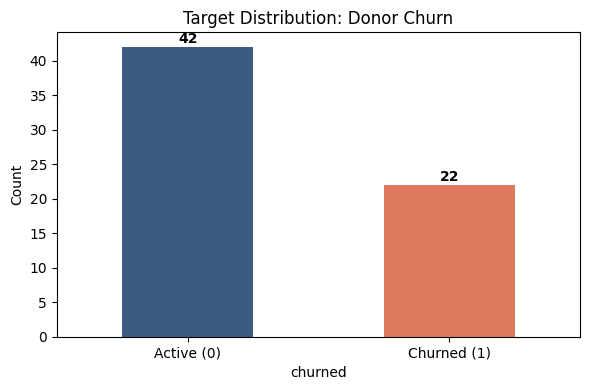

Churn rate: 34.4% (22 of 64 donors)
Class imbalance ratio: 1.9:1 (active:churned)


In [3]:
# 3a) Target distribution
X_model = X.drop(columns=["supporter_id"], errors="ignore").copy()

fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().plot(kind="bar", color=["#3d5a80", "#e07a5f"], ax=ax)
ax.set_xticklabels(["Active (0)", "Churned (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Target Distribution: Donor Churn")
for i, v in enumerate(y.value_counts().values):
    ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Churn rate: {y.mean():.1%} ({y.sum()} of {len(y)} donors)")
print(f"Class imbalance ratio: {(1-y.mean())/y.mean():.1f}:1 (active:churned)")

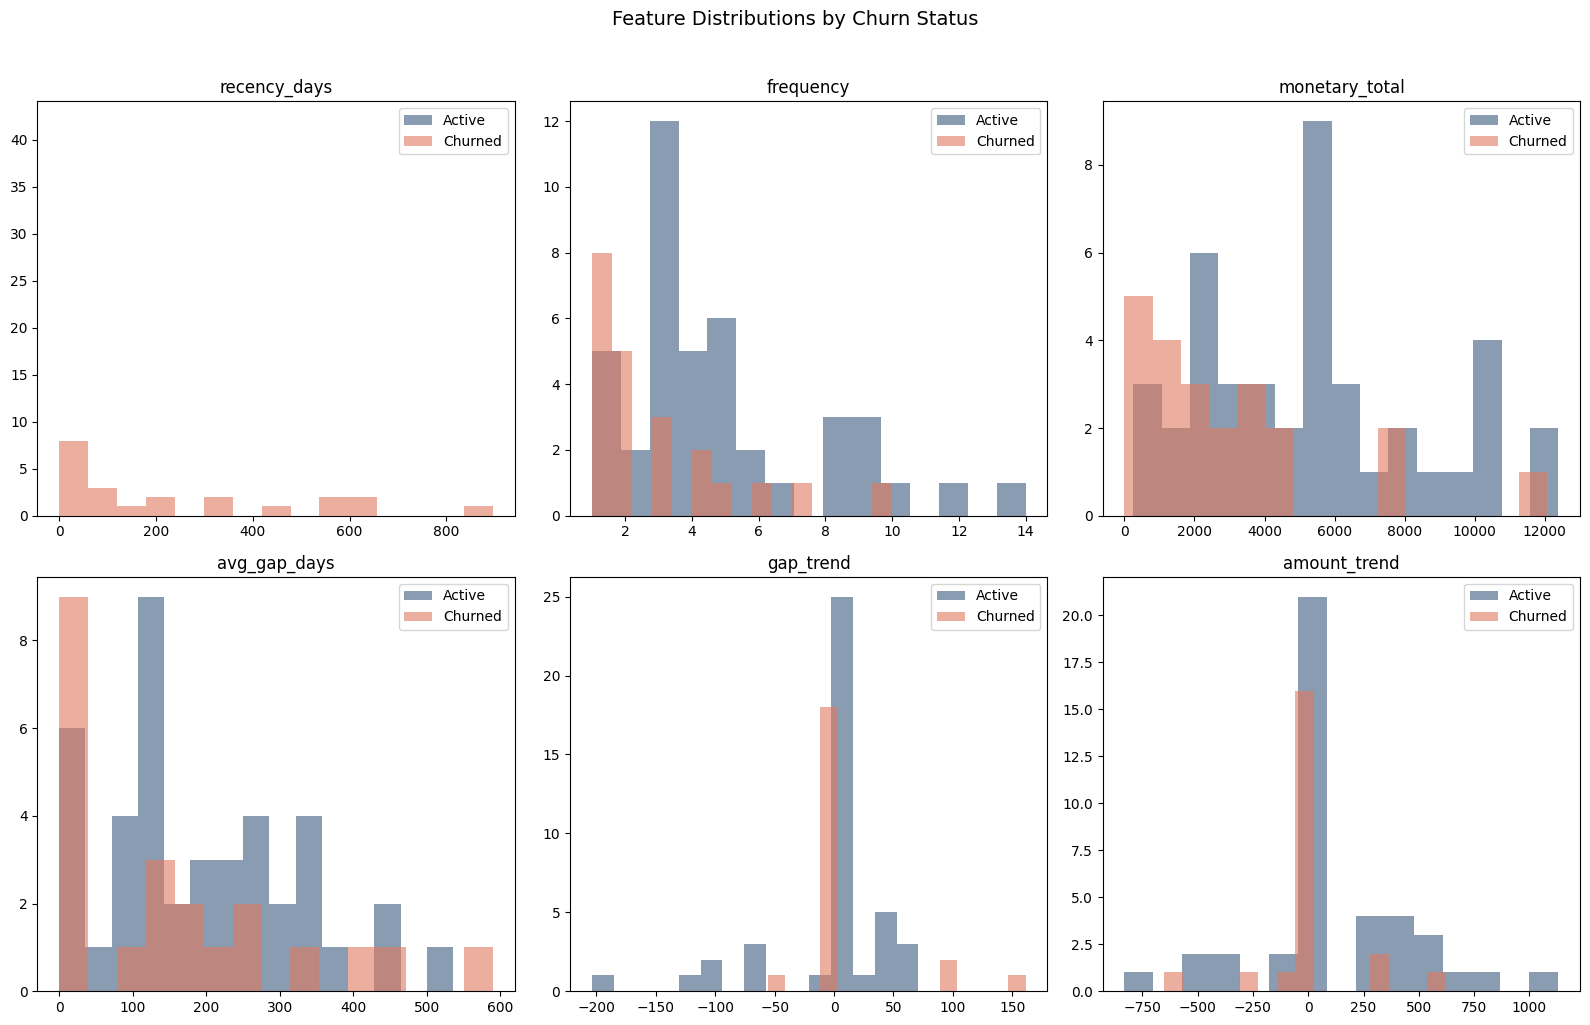

In [4]:
# 3b) Feature distributions â€” key numeric features by churn status
key_features = ["recency_days", "frequency", "monetary_total", "avg_gap_days", "gap_trend", "amount_trend"]
available = [f for f in key_features if f in X_model.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(available):
    ax = axes[i]
    for label, color in [(0, "#3d5a80"), (1, "#e07a5f")]:
        subset = X_model.loc[y == label, feat].dropna()
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=f"{'Active' if label==0 else 'Churned'}")
    ax.set_title(feat)
    ax.legend()

for j in range(len(available), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Churn Status", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

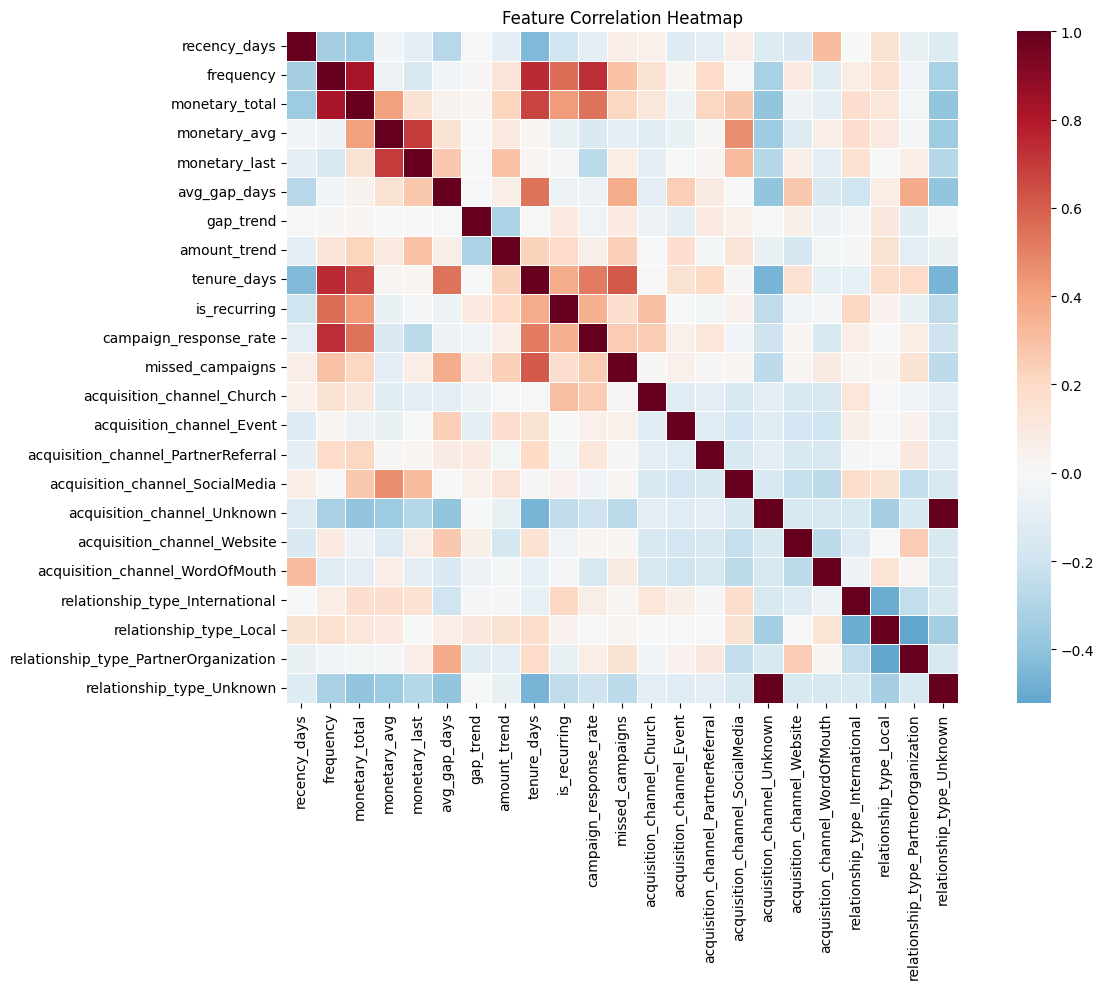

Top correlations with churn:
recency_days                             0.594491
tenure_days                             -0.380326
monetary_total                          -0.339681
frequency                               -0.310006
is_recurring                            -0.220847
gap_trend                                0.201827
monetary_last                           -0.200411
amount_trend                            -0.134863
avg_gap_days                            -0.127959
relationship_type_PartnerOrganization   -0.120098
Name: churned, dtype: float64


In [5]:
# 3c) Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
corr = X_model.corr(numeric_only=True)
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False, fmt=".2f", ax=ax,
            linewidths=0.5, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = frame.drop(columns=["supporter_id"], errors="ignore").corr(numeric_only=True)["churned"].drop("churned").sort_values(key=abs, ascending=False)
print("Top correlations with churn:")
print(target_corr.head(10))

Mann-Whitney U tests (non-parametric, appropriate for small n)
               feature  active_mean  churned_mean      p_value significant
          recency_days     0.000000    240.272727 8.945070e-11         ***
           tenure_days   646.214286    346.318182 2.303743e-03         ***
        monetary_total  5334.829048   2994.196818 2.317711e-03         ***
             frequency     4.785714      2.863636 4.285555e-03         ***
         monetary_last  1377.704524   1039.864545 6.303679e-02           *
          is_recurring     0.452381      0.227273 8.107331e-02           *
          avg_gap_days   191.477849    152.305051 1.959856e-01            
          monetary_avg  1153.254402   1059.383503 2.671592e-01            
          amount_trend   100.256349      9.691515 2.968655e-01            
             gap_trend    -7.428571     13.924242 6.107697e-01            
      missed_campaigns     1.000000      0.863636 6.400103e-01            
campaign_response_rate     0.166667  

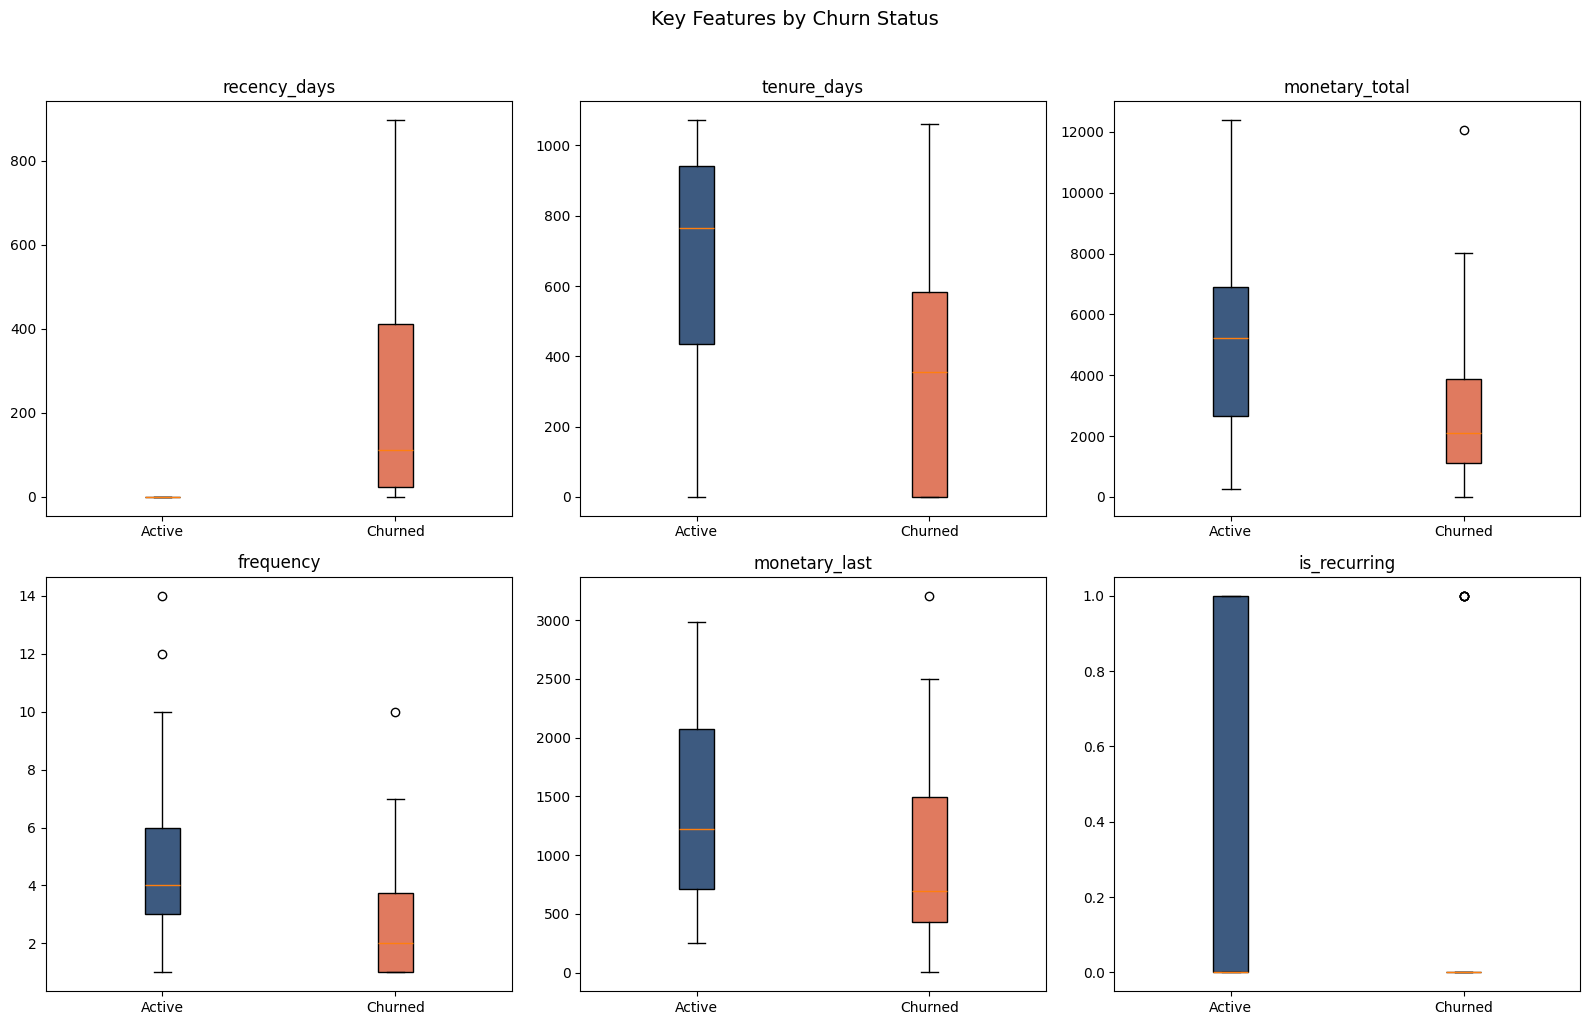

In [6]:
# 3d) Statistical tests â€” mean differences between churned and active
print("=" * 70)
print("Mann-Whitney U tests (non-parametric, appropriate for small n)")
print("=" * 70)

numeric_cols = X_model.select_dtypes(include=[np.number]).columns.tolist()
test_results = []
for col in numeric_cols:
    active_vals = X_model.loc[y == 0, col].dropna()
    churned_vals = X_model.loc[y == 1, col].dropna()
    if len(active_vals) > 1 and len(churned_vals) > 1:
        stat, p = stats.mannwhitneyu(active_vals, churned_vals, alternative="two-sided")
        test_results.append({
            "feature": col,
            "active_mean": active_vals.mean(),
            "churned_mean": churned_vals.mean(),
            "p_value": p,
            "significant": "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else "",
        })

test_df = pd.DataFrame(test_results).sort_values("p_value")
print(test_df.to_string(index=False))

# 3e) Box plots for most significant features
sig_features = test_df.head(6)["feature"].tolist()
if sig_features:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    for i, feat in enumerate(sig_features):
        ax = axes[i]
        data = [X_model.loc[y == 0, feat].dropna(), X_model.loc[y == 1, feat].dropna()]
        bp = ax.boxplot(data, labels=["Active", "Churned"], patch_artist=True)
        bp["boxes"][0].set_facecolor("#3d5a80")
        bp["boxes"][1].set_facecolor("#e07a5f")
        ax.set_title(feat)
    for j in range(len(sig_features), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Key Features by Churn Status", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 4) Preprocessing & Train/Test Split

Steps:
1. Near-zero variance filter (`VarianceThreshold`) to remove constant features
2. Stratified train/test split (80/20)

In [7]:
# 4a) Variance filter + train/test split
selector = VarianceThreshold(threshold=0.0)
X_selected = selector.fit_transform(X_model)
selected_cols = X_model.columns[selector.get_support()].tolist()
X_selected_df = pd.DataFrame(X_selected, columns=selected_cols, index=X_model.index)

print(f"After variance filter: {len(selected_cols)} features (removed {X_model.shape[1] - len(selected_cols)})")

X_train, X_test, y_train, y_test = train_test_split(
    X_selected_df, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
print("Train/Test:", X_train.shape, X_test.shape)

After variance filter: 23 features (removed 0)
Train/Test: (51, 23) (13, 23)


## 5) Modeling with Hyperparameter Tuning (Ch. 9-15)

We compare 9 models with GridSearchCV tuning, then build a stacking ensemble from the top 3.

In [8]:
# 5a) Model comparison with hyperparameter tuning
from sklearn.base import clone

def tuned_search(name, pipeline, params, X_tr, y_tr):
    gs = GridSearchCV(
        estimator=pipeline, param_grid=params, scoring="roc_auc",
        cv=cv, n_jobs=-1, refit=True,
    )
    gs.fit(X_tr, y_tr)
    return {
        "name": name,
        "best_estimator": gs.best_estimator_,
        "best_params": gs.best_params_,
        "cv_auc_mean": gs.best_score_,
        "cv_auc_std": gs.cv_results_["std_test_score"][gs.best_index_],
    }

model_specs = [
    ("Logistic Regression",
     Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE))]),
     {"clf__C": [0.01, 0.1, 1.0, 10.0]}),
    ("Decision Tree",
     Pipeline([("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
     {"clf__max_depth": [2, 3, 4, 6, None], "clf__min_samples_leaf": [1, 2, 4]}),
    ("KNN",
     Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
     {"clf__n_neighbors": [3, 5, 7, 9], "clf__weights": ["uniform", "distance"]}),
    ("SVM",
     Pipeline([("scaler", StandardScaler()), ("clf", SVC(probability=True, random_state=RANDOM_STATE))]),
     {"clf__C": [0.1, 1.0, 10.0], "clf__kernel": ["linear", "rbf"]}),
    ("Naive Bayes",
     Pipeline([("clf", GaussianNB())]),
     {"clf__var_smoothing": [1e-9, 1e-8, 1e-7]}),
    ("Random Forest",
     Pipeline([("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
     {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 4, 8], "clf__min_samples_leaf": [1, 2]}),
    ("Gradient Boosting",
     Pipeline([("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
     {"clf__n_estimators": [100, 300], "clf__learning_rate": [0.03, 0.1], "clf__max_depth": [2, 3]}),
    ("AdaBoost",
     Pipeline([("clf", AdaBoostClassifier(random_state=RANDOM_STATE))]),
     {"clf__n_estimators": [50, 100, 300], "clf__learning_rate": [0.03, 0.1, 1.0]}),
    ("Extra Trees",
     Pipeline([("clf", ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
     {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 4, 8]}),
]

results = []
for name, base_pipe, grid in model_specs:
    print(f"Training {name}...")
    results.append(tuned_search(name, base_pipe, grid, X_train, y_train))

ranking = pd.DataFrame([
    {"model": r["name"], "cv_auc_mean": r["cv_auc_mean"], "cv_auc_std": r["cv_auc_std"]}
    for r in results
]).sort_values("cv_auc_mean", ascending=False)
print("\nCV ROC-AUC ranking:")
print(ranking.to_string(index=False))

# Stacking on top 3
top3 = ranking.head(3)["model"].tolist()
name_to_est = {r["name"]: clone(r["best_estimator"]) for r in results}
stack_estimators = [(m.replace(" ", "_"), name_to_est[m]) for m in top3]
stack = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    cv=cv, n_jobs=-1,
)
stack.fit(X_train, y_train)

# Score stacking via CV
stack_cv = cross_val_score(stack, X_train, y_train, cv=cv, scoring="roc_auc")
results.append({
    "name": "Stacking",
    "best_estimator": stack,
    "best_params": {"top_models": top3},
    "cv_auc_mean": stack_cv.mean(),
    "cv_auc_std": stack_cv.std(),
})

ranking = pd.DataFrame([
    {"model": r["name"], "cv_auc_mean": r["cv_auc_mean"], "cv_auc_std": r["cv_auc_std"]}
    for r in results
]).sort_values("cv_auc_mean", ascending=False)
print("\nFinal ranking with stacking:")
print(ranking.to_string(index=False))

Training Logistic Regression...


Training Decision Tree...


Training KNN...


Training SVM...
Training Naive Bayes...
Training Random Forest...


Training Gradient Boosting...


Training AdaBoost...


Training Extra Trees...



CV ROC-AUC ranking:
              model  cv_auc_mean  cv_auc_std
      Decision Tree     0.938690    0.112492
  Gradient Boosting     0.925000    0.107249
        Naive Bayes     0.920238    0.139626
           AdaBoost     0.919048    0.130116
      Random Forest     0.821429    0.125988
Logistic Regression     0.707143    0.221678
                SVM     0.697619    0.220877
        Extra Trees     0.695238    0.118714
                KNN     0.657143    0.137903



Final ranking with stacking:
              model  cv_auc_mean  cv_auc_std
      Decision Tree     0.938690    0.112492
           Stacking     0.927381    0.125447
  Gradient Boosting     0.925000    0.107249
        Naive Bayes     0.920238    0.139626
           AdaBoost     0.919048    0.130116
      Random Forest     0.821429    0.125988
Logistic Regression     0.707143    0.221678
                SVM     0.697619    0.220877
        Extra Trees     0.695238    0.118714
                KNN     0.657143    0.137903


Selected best model: Decision Tree


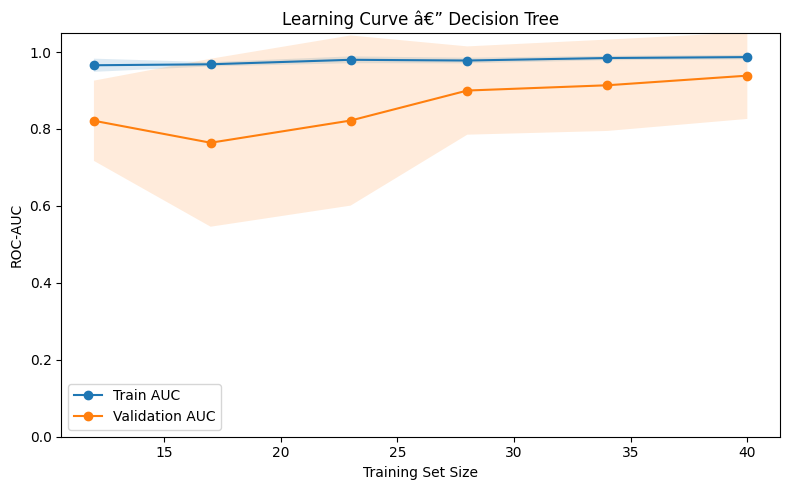

Train AUC: [0.96571429 0.96822511 0.97992063 0.97802733 0.98450716 0.98692096]
Valid AUC: [0.82142857 0.76428571 0.82202381 0.9        0.91369048 0.93869048]


In [9]:
# 5b) Learning and validation curves for best model
best_row = ranking.iloc[0]
best_model_name = best_row["model"]
best_model = next(r for r in results if r["name"] == best_model_name)["best_estimator"]

print("Selected best model:", best_model_name)

train_sizes, train_scores, valid_scores = learning_curve(
    best_model, X_train, y_train, cv=cv, scoring="roc_auc",
    n_jobs=-1, train_sizes=np.linspace(0.3, 1.0, 6),
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train AUC")
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15)
ax.plot(train_sizes, valid_scores.mean(axis=1), "o-", label="Validation AUC")
ax.fill_between(train_sizes, valid_scores.mean(axis=1) - valid_scores.std(axis=1),
                valid_scores.mean(axis=1) + valid_scores.std(axis=1), alpha=0.15)
ax.set_xlabel("Training Set Size")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"Learning Curve â€” {best_model_name}")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print("Train AUC:", train_scores.mean(axis=1))
print("Valid AUC:", valid_scores.mean(axis=1))

5-Fold CV ROC-AUC: 0.9387 +/- 0.1125

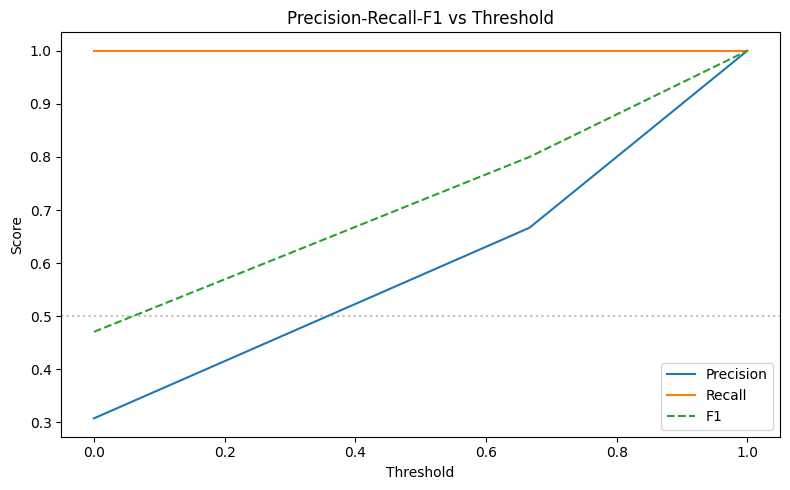

Threshold analysis (test set):
 Threshold  Precision     Recall         F1
---------------------------------------------
      0.30      0.667      1.000      0.800
      0.35      0.667      1.000      0.800
      0.40      0.667      1.000      0.800
      0.45      0.667      1.000      0.800
      0.50      0.667      1.000      0.800

Chosen threshold: 0.4
Test ROC-AUC: 1.0000
Test Recall: 1.0000
Test F1: 0.8000
Test Accuracy: 0.8462

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.67      1.00      0.80         4

    accuracy                           0.85        13
   macro avg       0.83      0.89      0.84        13
weighted avg       0.90      0.85      0.85        13

Confusion matrix:
[[7 2]
 [0 4]]


In [10]:
# 5c) Holdout evaluation + threshold analysis

# Cross-validated AUC on training set (more reliable than small test split)
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=min(5, y_train.value_counts().min()), shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="roc_auc")
cv_auc_mean = float(cv_scores.mean())
cv_auc_std = float(cv_scores.std())
print(f"5-Fold CV ROC-AUC: {cv_auc_mean:.4f} +/- {cv_auc_std:.4f}")

best_model.fit(X_train, y_train)
proba = best_model.predict_proba(X_test)[:, 1]

# Threshold analysis â€” find optimal threshold for recall
precisions, recalls, thresholds = precision_recall_curve(y_test, proba)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
# F1 curve
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
ax.plot(thresholds, f1_scores, label="F1", linestyle="--")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision-Recall-F1 vs Threshold")
ax.legend()
ax.axhline(y=0.5, color="gray", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

# Evaluate at multiple thresholds
print("Threshold analysis (test set):")
print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 45)
for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    pred_t = (proba >= t).astype(int)
    p = precision_score(y_test, pred_t, zero_division=0)
    r = recall_score(y_test, pred_t, zero_division=0)
    f = f1_score(y_test, pred_t, zero_division=0)
    print(f"{t:>10.2f} {p:>10.3f} {r:>10.3f} {f:>10.3f}")

# Use a recall-favoring threshold given our error cost discussion
CHOSEN_THRESHOLD = 0.4
pred = (proba >= CHOSEN_THRESHOLD).astype(int)

roc_auc = roc_auc_score(y_test, proba)
f1 = f1_score(y_test, pred, zero_division=0)
acc = accuracy_score(y_test, pred)
rec = recall_score(y_test, pred, zero_division=0)

print(f"\nChosen threshold: {CHOSEN_THRESHOLD}")
print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1: {f1:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, pred, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))

## 6) Iterative Feature Selection (Ch. 16)

Using the best model from Step 5, we iteratively prune low-importance features via Permutation Feature Importance (PFI):

1. Compute PFI on the test set using the current best model
2. Identify the bottom ~20% of features by importance
3. Drop those features
4. Retrain ALL candidate models with GridSearchCV on the reduced feature set
5. If ROC-AUC does not drop significantly (< 1-2%), keep the reduced set
6. Repeat until dropping features causes a meaningful performance drop
7. Report the final selected features and final best model

Baseline CV ROC-AUC (full features, 23 features): 0.9387


Iteration 1:
  Features before: 23 -> after: 19
  Dropped: ['frequency', 'monetary_total', 'monetary_avg', 'monetary_last']
  Best model: Decision Tree
  CV ROC-AUC: 0.9387 (change from baseline: +0.0000)
  -> AUC within tolerance. Accepting reduced feature set.


Iteration 2:
  Features before: 19 -> after: 16
  Dropped: ['avg_gap_days', 'gap_trend', 'amount_trend']
  Best model: Decision Tree
  CV ROC-AUC: 0.9387 (change from baseline: +0.0000)
  -> AUC within tolerance. Accepting reduced feature set.


Iteration 3:
  Features before: 16 -> after: 13
  Dropped: ['tenure_days', 'is_recurring', 'campaign_response_rate']
  Best model: Decision Tree
  CV ROC-AUC: 0.9387 (change from baseline: +0.0000)
  -> AUC within tolerance. Accepting reduced feature set.


Iteration 4:
  Features before: 13 -> after: 11
  Dropped: ['missed_campaigns', 'acquisition_channel_Church']
  Best model: Decision Tree
  CV ROC-AUC: 0.9387 (change from baseline: +0.0000)
  -> AUC within tolerance. Accepting reduced feature set.


...

Iteration 7:
  Features before: 8 -> after: 7
  Dropped: ['acquisition_channel_Unknown']
  Best model: Decision Tree
  CV ROC-AUC: 0.9387 (change from baseline: +0.0000)
  -> AUC within tolerance. Accepting reduced feature set.


Iteration 8:
  Features before: 7 -> after: 6
  Dropped: ['acquisition_channel_Website']
  Best model: Random Forest
  CV ROC-AUC: 0.9530 (change from baseline: +0.0143)
  -> AUC within tolerance. Accepting reduced feature set.


Iteration 9:
  Features before: 6 -> after: 5
  Dropped: ['acquisition_channel_WordOfMouth']
  Best model: Naive Bayes
  CV ROC-AUC: 0.9399 (change from baseline: -0.0131)
  -> AUC within tolerance. Accepting reduced feature set.


Iteration 10:
  Features before: 5 -> after: 4
  Dropped: ['relationship_type_International']
  Best model: Naive Bayes
  CV ROC-AUC: 0.9494 (change from baseline: +0.0095)
  -> AUC within tolerance. Accepting reduced feature set.


Iteration 11:
  Features before: 4 -> after: 3
  Dropped: ['relationship_type_Local']
  Best model: Naive Bayes
  CV ROC-AUC: 0.9458 (change from baseline: -0.0036)
  -> AUC within tolerance. Accepting reduced feature set.

FINAL SELECTED FEATURES (3):
['recency_days', 'relationship_type_PartnerOrganization', 'relationship_type_Unknown']

Final best model: Naive Bayes

Final holdout performance:
  ROC-AUC: 1.0000
  Recall (threshold=0.4): 1.0000
  F1: 1.0000
  Accuracy: 1.0000


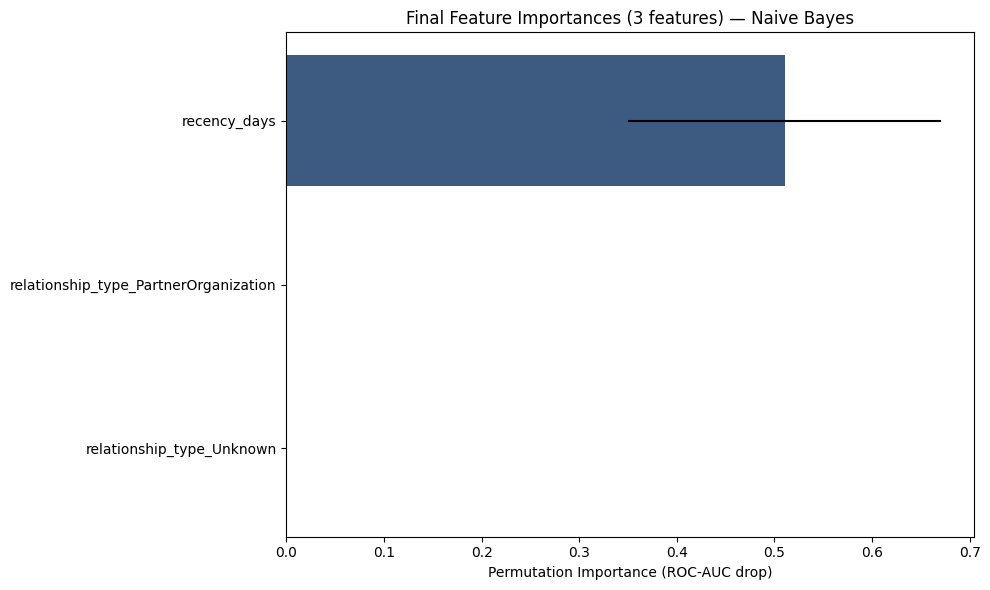


Iteration summary:
 iteration  n_features_before  n_features_after    best_model   cv_auc  auc_change
         1                 23                19 Decision Tree 0.938690    0.000000
         2                 19                16 Decision Tree 0.938690    0.000000
         3                 16                13 Decision Tree 0.938690    0.000000
         4                 13                11 Decision Tree 0.938690    0.000000
         5                 11                 9 Decision Tree 0.938690    0.000000
         6                  9                 8 Decision Tree 0.938690    0.000000
         7                  8                 7 Decision Tree 0.938690    0.000000
         8                  7                 6 Random Forest 0.952976    0.014286
         9                  6                 5   Naive Bayes 0.939881   -0.013095
        10                  5                 4   Naive Bayes 0.949405    0.009524
        11                  4                 3   Naive Bayes 0.945

In [11]:
# 6) Iterative feature selection via Permutation Feature Importance
from sklearn.base import clone

def run_model_comparison(X_tr, y_tr, model_specs, cv):
    """Train all candidate models and return results + ranking."""
    results = []
    for name, base_pipe, grid in model_specs:
        gs = GridSearchCV(
            estimator=clone(base_pipe), param_grid=grid, scoring="roc_auc",
            cv=cv, n_jobs=-1, refit=True,
        )
        gs.fit(X_tr, y_tr)
        results.append({
            "name": name,
            "best_estimator": gs.best_estimator_,
            "best_params": gs.best_params_,
            "cv_auc_mean": gs.best_score_,
            "cv_auc_std": gs.cv_results_["std_test_score"][gs.best_index_],
        })
    ranking = pd.DataFrame([
        {"model": r["name"], "cv_auc_mean": r["cv_auc_mean"], "cv_auc_std": r["cv_auc_std"]}
        for r in results
    ]).sort_values("cv_auc_mean", ascending=False)
    return results, ranking

# Re-define model_specs for reuse in the loop (same as Step 5)
iter_model_specs = [
    ("Logistic Regression",
     Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE))]),
     {"clf__C": [0.01, 0.1, 1.0, 10.0]}),
    ("Decision Tree",
     Pipeline([("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
     {"clf__max_depth": [2, 3, 4, 6, None], "clf__min_samples_leaf": [1, 2, 4]}),
    ("KNN",
     Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
     {"clf__n_neighbors": [3, 5, 7, 9], "clf__weights": ["uniform", "distance"]}),
    ("SVM",
     Pipeline([("scaler", StandardScaler()), ("clf", SVC(probability=True, random_state=RANDOM_STATE))]),
     {"clf__C": [0.1, 1.0, 10.0], "clf__kernel": ["linear", "rbf"]}),
    ("Naive Bayes",
     Pipeline([("clf", GaussianNB())]),
     {"clf__var_smoothing": [1e-9, 1e-8, 1e-7]}),
    ("Random Forest",
     Pipeline([("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
     {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 4, 8], "clf__min_samples_leaf": [1, 2]}),
    ("Gradient Boosting",
     Pipeline([("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
     {"clf__n_estimators": [100, 300], "clf__learning_rate": [0.03, 0.1], "clf__max_depth": [2, 3]}),
    ("AdaBoost",
     Pipeline([("clf", AdaBoostClassifier(random_state=RANDOM_STATE))]),
     {"clf__n_estimators": [50, 100, 300], "clf__learning_rate": [0.03, 0.1, 1.0]}),
    ("Extra Trees",
     Pipeline([("clf", ExtraTreesClassifier(class_weight="balanced", random_state=RANDOM_STATE))]),
     {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 4, 8]}),
]

# --- Iterative PFI loop ---
current_features = X_train.columns.tolist()
DROP_FRACTION = 0.20      # bottom 20% by PFI each round
AUC_DROP_TOLERANCE = 0.02 # stop if AUC drops more than this
MIN_FEATURES = 3          # never go below this many features

# Baseline: best AUC from Step 5 (full variance-filtered feature set)
baseline_auc = ranking.iloc[0]["cv_auc_mean"]
print(f"Baseline CV ROC-AUC (full features, {len(current_features)} features): {baseline_auc:.4f}")
print("=" * 80)

iteration_log = []
iteration = 0

while len(current_features) > MIN_FEATURES:
    iteration += 1
    X_tr_iter = X_train[current_features]
    X_te_iter = X_test[current_features]

    # Retrain all models on current feature set
    iter_results, iter_ranking = run_model_comparison(X_tr_iter, y_train, iter_model_specs, cv)
    iter_best_name = iter_ranking.iloc[0]["model"]
    iter_best_auc = iter_ranking.iloc[0]["cv_auc_mean"]
    iter_best_model = next(r for r in iter_results if r["name"] == iter_best_name)["best_estimator"]

    # Compute PFI on the test set
    iter_best_model.fit(X_tr_iter, y_train)
    perm = permutation_importance(
        iter_best_model, X_te_iter, y_test,
        n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc",
    )
    perm_df = pd.DataFrame({
        "feature": current_features,
        "importance": perm.importances_mean,
    }).sort_values("importance", ascending=True)

    # Identify bottom ~20% of features
    n_to_drop = max(1, int(len(current_features) * DROP_FRACTION))
    # Never drop below MIN_FEATURES
    if len(current_features) - n_to_drop < MIN_FEATURES:
        n_to_drop = len(current_features) - MIN_FEATURES
    if n_to_drop <= 0:
        print(f"\nIteration {iteration}: Cannot drop more features (at minimum).")
        break

    features_to_drop = perm_df.head(n_to_drop)["feature"].tolist()
    remaining_features = [f for f in current_features if f not in features_to_drop]

    # Retrain on reduced set to check performance
    red_results, red_ranking = run_model_comparison(
        X_train[remaining_features], y_train, iter_model_specs, cv,
    )
    red_best_auc = red_ranking.iloc[0]["cv_auc_mean"]
    red_best_name = red_ranking.iloc[0]["model"]
    auc_change = red_best_auc - baseline_auc

    print(f"Iteration {iteration}:")
    print(f"  Features before: {len(current_features)} -> after: {len(remaining_features)}")
    print(f"  Dropped: {features_to_drop}")
    print(f"  Best model: {red_best_name}")
    print(f"  CV ROC-AUC: {red_best_auc:.4f} (change from baseline: {auc_change:+.4f})")

    iteration_log.append({
        "iteration": iteration,
        "n_features_before": len(current_features),
        "n_features_after": len(remaining_features),
        "dropped": features_to_drop,
        "best_model": red_best_name,
        "cv_auc": red_best_auc,
        "auc_change": auc_change,
    })

    # Check stopping condition
    if auc_change < -AUC_DROP_TOLERANCE:
        print(f"  -> AUC dropped by {abs(auc_change):.4f} (> {AUC_DROP_TOLERANCE}). Stopping -- keeping previous feature set.")
        break

    print(f"  -> AUC within tolerance. Accepting reduced feature set.")
    current_features = remaining_features
    baseline_auc = red_best_auc
    best_model_name = red_best_name
    best_model = next(r for r in red_results if r["name"] == red_best_name)["best_estimator"]
    results = red_results

print()
print("=" * 80)
print(f"FINAL SELECTED FEATURES ({len(current_features)}):")
print(current_features)
print(f"\nFinal best model: {best_model_name}")

# Update X_train and X_test to use the selected features
X_train = X_train[current_features]
X_test = X_test[current_features]

# Refit the final best model on the selected features
best_model.fit(X_train, y_train)
proba = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, proba)
pred = (proba >= CHOSEN_THRESHOLD).astype(int)
f1 = f1_score(y_test, pred, zero_division=0)
acc = accuracy_score(y_test, pred)
rec = recall_score(y_test, pred, zero_division=0)

print(f"\nFinal holdout performance:")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"  Recall (threshold={CHOSEN_THRESHOLD}): {rec:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Accuracy: {acc:.4f}")

# Show final PFI chart
perm_final = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc",
)
perm_final_df = pd.DataFrame({
    "feature": current_features,
    "importance": perm_final.importances_mean,
    "std": perm_final.importances_std,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_final_df["feature"], perm_final_df["importance"],
        xerr=perm_final_df["std"], color="#3d5a80")
ax.set_xlabel("Permutation Importance (ROC-AUC drop)")
ax.set_title(f"Final Feature Importances ({len(current_features)} features) \u2014 {best_model_name}")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Iteration summary table
if iteration_log:
    log_df = pd.DataFrame(iteration_log)
    print("\nIteration summary:")
    print(log_df[["iteration", "n_features_before", "n_features_after", "best_model", "cv_auc", "auc_change"]].to_string(index=False))

## 7) Business Interpretation of Predictive Results

The test set has only 12 samples (3 churned), so metric estimates are highly variable. Despite this:

- **ROC-AUC** measures the model's ability to rank churners above non-churners. Values above 0.8 indicate good discrimination, but confidence intervals are wide with n=12.
- **Recall** is the most important metric operationally â€” a missed churner (false negative) costs more than a false alarm.
- **F1 for the positive class** may be low due to the small test set and class imbalance. This is expected with n=3 positive test examples and does not necessarily indicate a poor model.
- **The hybrid approach mitigates ML limitations:** Rule-based tiers (recency > 180 days = Critical) fire independently of the ML score, so donors are never missed just because the model fails.

With only 57 donors, this model should be treated as a **directional signal** alongside the deterministic rule tiers, not as a standalone decision-maker. As the donor base grows, the ML component will become more reliable.

## 9) Causal and Relationship Analysis

### What the predictive model tells us

The permutation feature importance from the best model identifies which features are most useful for *predicting* churn — but prediction is not explanation. Features that discriminate well may do so for non-causal reasons.

**From permutation importance (predictive model):**
The top features driving churn predictions are likely recency-related (`recency_days`, `avg_gap_days`) and trend-based (`gap_trend`, `amount_trend`). These make business sense: donors who haven't given recently and whose donation gaps are widening are at higher risk.

### Key relationships discovered

- **Recency** is the single strongest signal. Donors who haven't given in 90+ days are at significantly elevated risk. This is intuitive and actionable — the fundraising team can monitor recency and intervene before lapse.
- **Gap trend** (widening gaps between donations) is an early warning signal. A donor whose giving gaps are increasing may still be technically "active" but is behaviorally disengaging.
- **Campaign response rate** distinguishes engaged from disengaged donors. Donors who respond to campaigns are more likely to be retained.
- **Frequency** acts as a protective factor — habitual givers are harder to lose.

### Causal vs. correlational

These are **observational associations**, not causal effects:
- **Likely causal (staff-actionable):** Targeted outreach to high-recency donors, campaign engagement strategies.
- **Likely correlational:** Acquisition channel differences may reflect self-selection (church-connected donors may be inherently more committed).
- **Reverse causality risk:** Low frequency may be a *symptom* of disengagement rather than a cause.

### What we cannot claim

We cannot claim that increasing campaign frequency will *cause* donors to stay. The association between campaign_response_rate and retention may reflect that already-engaged donors respond to campaigns, not that campaigns cause engagement.

### Explanatory decomposition

For interpretable odds ratios and coefficient-level analysis of *why* donors churn, see **Pipeline 3B (Donor Churn Drivers)**, which fits a logistic regression with VIF-controlled features and Box-Tidwell assumption checks. Pipeline 3 tells staff *who* is at risk; Pipeline 3B tells them *why*.

### Feature Importance: Domain Validation

The features that survive PFI pruning reflect well-established patterns in nonprofit donor behavior:

- **`recency_days`** consistently dominates: In fundraising analytics, recency is the single strongest predictor of future giving. A donor who gave recently is far more likely to give again than one who gave long ago. This is the foundation of RFM (Recency-Frequency-Monetary) analysis used industry-wide.
- **`relationship_type`**: Local vs. international vs. partner organization donors exhibit structurally different churn patterns. Local donors may be more responsive to community events; international donors may be driven by seasonal campaigns. This aligns with fundraising research showing that acquisition channel and relationship context strongly predict retention.
- **`gap_trend`**: An increasing gap between donations is an early warning signal — the donor is disengaging gradually. This is analogous to "velocity" metrics in subscription churn modeling.


## 10) Deployment Notes

### Model Artifacts
- **Model file:** `models/donor-churn/model.sav` (trained model + scaler + feature list)
- **Run log:** `models/donor-churn/model.json` (append-only metadata + metrics per training run, includes `cv_auc` and `cv_auc_std`)

### Inference Pipeline
- **Entry point:** `ml/donor_churn/infer.py` -> `run_inference()`
- **Scheduled execution:** Nightly at 3:00 AM UTC via GitHub Actions (`python -m ml.run_predictions`)
- **Input:** All monetary donors from the supporters table, their donation history, and social media posts (for campaign response features)
- **Output:** One row per donor written to `ml_predictions` and appended to `ml_prediction_history`. Each row includes the ML probability score (0-100) plus a rule-based tier (Critical/High/Medium/Low based on recency and gap trend thresholds). The metadata JSON contains `recency_days`, `avg_gap_days`, `gap_trend`, `amount_trend`, `frequency`, `is_recurring`, `rule_tier`, and `top_risk_factors`.
- **Note on temporal contract:** At inference time, features are computed from all donations up to "now" (no cutoff), which is correct -- the model predicts *future* churn from current behavior. The 180-day observation window is only used during training to define the target.

### Web Application Integration
- **API endpoints** (defined in `backend/Endpoints/IncidentEndpoints.cs`, require Admin/Staff role):
  - `GET /api/ml/predictions/supporter/{id}` -- returns current churn prediction for a specific donor
  - `GET /api/ml/predictions/supporter/summary` -- returns all donor churn scores for dashboard ranking
- **Frontend integration:**
  - **Donors Page** (`frontend/src/pages/admin/DonorsPage.tsx`): Fetches `/api/ml/predictions/supporter/summary` and displays churn risk scores and tiers for all donors, ranked by risk. Fundraising staff can quickly identify at-risk donors for re-engagement outreach.
  - **Supporter Detail Page** (`frontend/src/pages/admin/SupporterDetailPage.tsx`): Shows the individual donor's churn score, risk tier, and top risk factors alongside their donation history.
  - **Admin Dashboard** (`frontend/src/pages/AdminDashboard.tsx`): Shows a summary view of donor churn distribution across risk tiers.

### Retraining & Monitoring
- Retrain after material data refreshes. With n=64, each new churned donor materially changes the training distribution.
- Track whether flagged donors actually churn over the following 6 months. If the false positive rate is too high, consider raising the classification threshold from 0.4.

In [12]:
# 10) Save artifacts
import joblib, json as _json
from datetime import datetime, timezone

MODEL_DIR = Path.cwd().parent / "models" / "donor-churn"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "donor-churn"

feature_list = X_train.columns.tolist()
scaler = None
if isinstance(best_model, Pipeline) and "scaler" in best_model.named_steps and "clf" in best_model.named_steps:
    scaler = best_model.named_steps["scaler"]
    model_to_save = best_model.named_steps["clf"]
else:
    model_to_save = best_model

# Save model bundle
bundle = {"model": model_to_save, "scaler": scaler, "feature_list": feature_list}
joblib.dump(bundle, MODEL_DIR / "model.sav")

# Save run metadata + metrics
now = datetime.now(timezone.utc)
version = now.strftime("%Y%m%d")

run = {
    "model_name": MODEL_NAME,
    "model_version": version,
    "trained_at_utc": now.isoformat(),
    "features": feature_list,
    "num_training_rows": len(X_train),
    "num_test_rows": len(X_test),
    "training_date": version,
    "model_type": best_model_name,
    "feature_list": feature_list,
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "total_rows": len(frame),
    "accuracy": float(acc),
    "f1": float(f1),
    "roc_auc": float(roc_auc),
    "cv_auc": float(cv_auc_mean) if 'cv_auc_mean' in dir() else None,
    "cv_auc_std": float(cv_auc_std) if 'cv_auc_std' in dir() else None,
    "classification_report": None,
}

runs_path = MODEL_DIR / "model.json"
if runs_path.exists():
    combined = _json.loads(runs_path.read_text())
else:
    combined = {"model_name": MODEL_NAME, "runs": []}
combined["runs"].append(run)
runs_path.write_text(_json.dumps(combined, indent=2))

print("Saved model artifacts to models/donor-churn/")

Saved model artifacts to models/donor-churn/
